# Task 6 — Customer Churn Prediction

This project analyzes customer churn using the Telco Customer Churn dataset. The goal is to understand which customer characteristics are associated with churn and compare Decision Tree and Logistic Regression models for churn prediction.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 7043
Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df['TotalCharges'].dtype

dtype('O')

In [10]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

In [12]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Missing Value Handling

The `TotalCharges` column contained some blank values that were interpreted as missing after converting the column to numeric format. Since `TotalCharges` is a numerical feature, I replaced the missing values with the median of the column. Using the median reduces the effect of unusually high or low charges compared with using the mean.

In [13]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [14]:
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


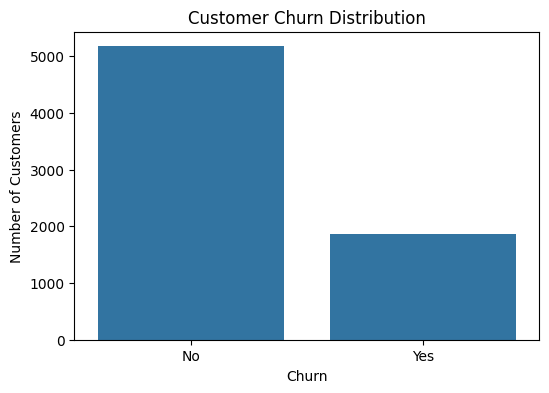

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Churn')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Class Imbalance

The dataset contains more customers who did not churn than customers who churned. This creates a class imbalance because the two target classes are not equally represented. To account for this during model training, I will use `class_weight='balanced'` for both the Decision Tree and Logistic Regression models. This gives more importance to the minority churn class.

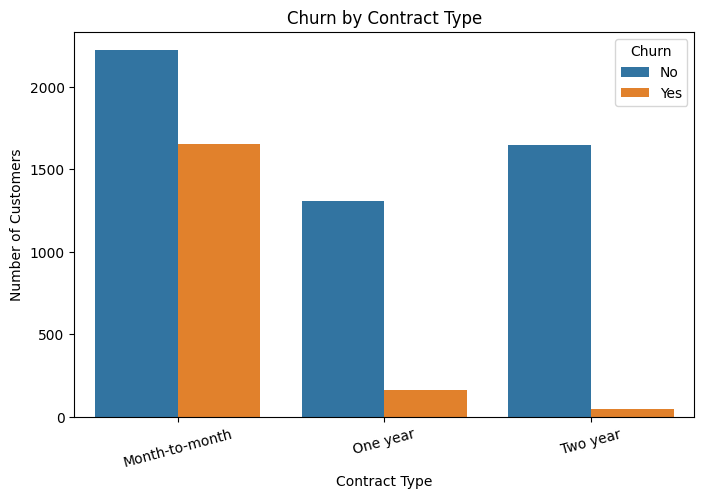

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)
plt.show()

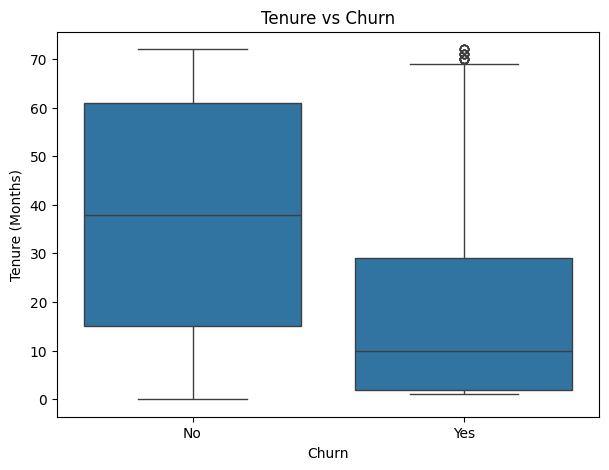

In [17]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

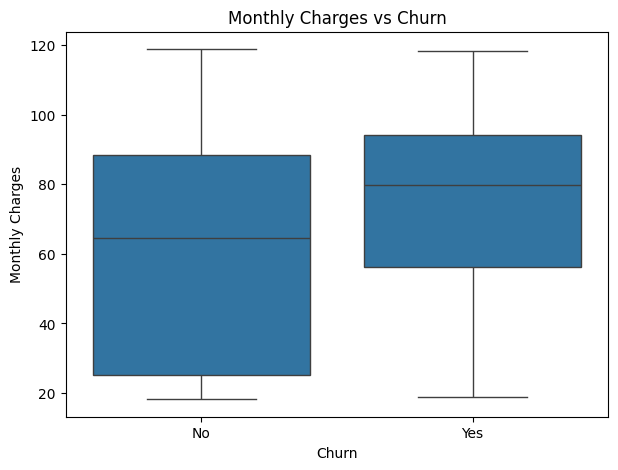

In [18]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [19]:
df_model = df.copy()

In [20]:
df_model = df_model.drop(columns=['customerID'])

In [21]:
df_model['Churn'] = df_model['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [22]:
df_model['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [23]:
df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

In [24]:
df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [25]:
X = df_model.drop(columns=['Churn'])

y = df_model['Churn']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=5
)

decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [28]:
tree_pred = decision_tree.predict(X_test)

In [29]:
print("Decision Tree Accuracy:")
print(f"{accuracy_score(y_test, tree_pred):.2%}")

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, tree_pred))

Decision Tree Accuracy:
73.46%

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409



In [30]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

logistic_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [31]:
logistic_pred = logistic_model.predict(X_test)

In [32]:
print("Logistic Regression Accuracy:")
print(f"{accuracy_score(y_test, logistic_pred):.2%}")

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, logistic_pred))

Logistic Regression Accuracy:
73.88%

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [33]:
tree_accuracy = accuracy_score(y_test, tree_pred)
logistic_accuracy = accuracy_score(y_test, logistic_pred)

comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Logistic Regression'
    ],
    'Accuracy': [
        tree_accuracy,
        logistic_accuracy
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.734564
1,Logistic Regression,0.738822


In [34]:
from sklearn.metrics import f1_score

tree_f1 = f1_score(y_test, tree_pred)
logistic_f1 = f1_score(y_test, logistic_pred)

model_comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Logistic Regression'
    ],
    'Accuracy': [
        tree_accuracy,
        logistic_accuracy
    ],
    'F1 Score': [
        tree_f1,
        logistic_f1
    ]
})

model_comparison

,Model,Accuracy,F1 Score
0,Decision Tree,0.734564,0.617587
1,Logistic Regression,0.738822,0.615866


In [35]:
model_comparison_style = model_comparison.copy()

for col in ['Accuracy', 'F1 Score']:
    model_comparison_style[col] = model_comparison_style[col].map(
        lambda x: f"{x:.2%}"
    )

model_comparison_style

,Model,Accuracy,F1 Score
0,Decision Tree,73.46%,61.76%
1,Logistic Regression,73.88%,61.59%


In [36]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
25,Contract_Two year,0.405269
24,Contract_One year,0.253452
10,InternetService_Fiber optic,0.111558
1,tenure,0.094694
23,StreamingMovies_Yes,0.034102
3,TotalCharges,0.027222
28,PaymentMethod_Electronic check,0.020621
2,MonthlyCharges,0.019440
11,InternetService_No,0.015233
7,PhoneService_Yes,0.012017


In [37]:
top_3_features = feature_importance.head(3)

top_3_features

,Feature,Importance
25,Contract_Two year,0.405269
24,Contract_One year,0.253452
10,InternetService_Fiber optic,0.111558


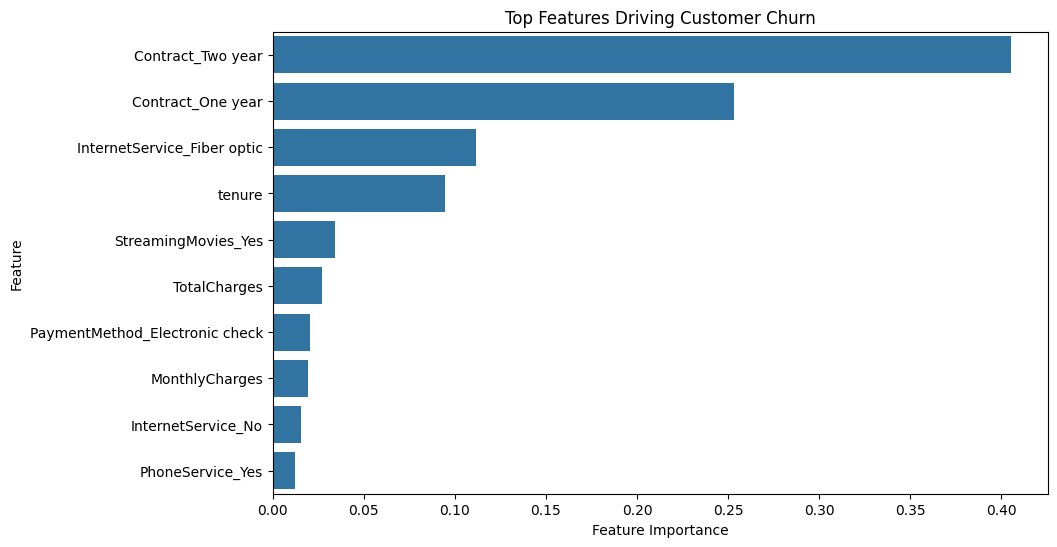

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top Features Driving Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

## Top 3 Features Driving Churn

According to the Decision Tree feature importance results, the top three features associated with churn are:

1. **[Contract_Two year]**
2. **[Contract One year]**
3. **[InternetService_Fiber optic]**

These features appear to have the strongest influence on the Decision Tree's churn predictions. However, feature importance shows how useful a feature was to the model and does not necessarily prove that the feature directly causes customers to churn.

In [ ]:
tree_cm = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    tree_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
logistic_cm = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Business Summary

The analysis shows that some customer characteristics are strongly associated with the likelihood of churn. The Decision Tree identified **[Contract Two year]**, **[Contract One year]**, and **[InternetService_Fiber optic]** as the three most important features for predicting churn. Customers with characteristics associated with higher churn risk could be targeted with retention offers, improved service plans, or personalized support. I compared Decision Tree and Logistic Regression models and evaluated them using both accuracy and F1-score because the dataset contains more non-churning customers than churning customers. These findings can help the business identify higher-risk customers earlier and focus retention efforts where they are most likely to have an impact.